Primera parte, cargar los datos a un df de pandas


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import os
from dotenv import load_dotenv


# Conectar a Mongo y extraer datos
load_dotenv()

URI = os.getenv("MONGO_URI")
cliente = MongoClient(URI)
coleccion = cliente["taller4_db"]["raw_data"]

# Convertir a DataFrame
datos_mongo = list(coleccion.find())
df = pd.DataFrame(datos_mongo)
print(f"Registros extraídos de la base de datos: {len(df)}")

Registros extraídos de la base de datos: 800


Segunda parte seleccion de variables, analisis basico

In [2]:
# 1. Definir las 5 columnas requeridas según la guía del taller
columnas_interes = ['name', 'status', 'species', 'gender', 'type']

# 2. Crear el DataFrame limpio a partir del original
df_limpio = df[columnas_interes].copy()

# 3. Limpieza de datos: En la API de Rick & Morty, la columna 'type' suele venir vacía ('') 
# si el personaje no tiene subtipo. Reemplazamos los textos vacíos por 'Desconocido'.
df_limpio['type'] = df_limpio['type'].replace('', 'Desconocido')


print("¡Filtrado y limpieza inicial completados con éxito!")

# Visualizacion del df

print("=== 1. PRIMEROS 5 REGISTROS ===")
display(df_limpio.head())

print("\n=== 2. INFORMACIÓN GENERAL Y TIPOS DE DATOS ===")
df_limpio.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_limpio.isnull().sum())



¡Filtrado y limpieza inicial completados con éxito!
=== 1. PRIMEROS 5 REGISTROS ===


,name,status,species,gender,type
0,Rick Sanchez,Alive,Human,Male,Desconocido
1,Morty Smith,Alive,Human,Male,Desconocido
2,Summer Smith,Alive,Human,Female,Desconocido
3,Beth Smith,Alive,Human,Female,Desconocido
4,Jerry Smith,Alive,Human,Male,Desconocido



=== 2. INFORMACIÓN GENERAL Y TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   name     800 non-null    str  
 1   status   800 non-null    str  
 2   species  800 non-null    str  
 3   gender   800 non-null    str  
 4   type     800 non-null    str  
dtypes: str(5)
memory usage: 31.4 KB

=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===
name       0
status     0
species    0
gender     0
type       0
dtype: int64


Creacion de 5 insights basicos 

In [3]:
print("--- GENERACIÓN DE INSIGHTS NUMÉRICOS ---\n")

# Insight 1: Total de observaciones extraídas
total_personajes = len(df_limpio)
print(f"1. Total de personajes evaluados en la muestra: {total_personajes}")

# Insight 2: Proporción de personajes en estado 'Alive' (Vivos)
personajes_vivos = len(df_limpio[df_limpio['status'] == 'Alive'])
porcentaje_vivos = round((personajes_vivos / total_personajes) * 100, 2)
print(f"2. Estado vital preponderante: El {porcentaje_vivos}% de los personajes se encuentran actualmente vivos.")

# Insight 3: Especie dominante dentro del universo analizado
especie_principal = df_limpio['species'].mode()[0]
conteo_especie = df_limpio['species'].value_counts().iloc[0]
print(f"3. Especie dominante: La especie más común es '{especie_principal}' con un total de {conteo_especie} individuos.")

# Insight 4: Diversidad biológica/género en el dataset
cantidad_generos = df_limpio['gender'].nunique()
print(f"4. Variabilidad de género: Se identificaron {cantidad_generos} clasificaciones de género diferentes.")

# Insight 5: Cantidad de personajes con subtipo o características raras/específicas
conteo_subtipos_reales = len(df_limpio[df_limpio['type'] != 'Desconocido'])
print(f"5. Especificidad de subtipos: Existen {conteo_subtipos_reales} personajes que poseen un subtipo o propiedad especial listada en la variable 'type'.")

--- GENERACIÓN DE INSIGHTS NUMÉRICOS ---

1. Total de personajes evaluados en la muestra: 800
2. Estado vital preponderante: El 54.37% de los personajes se encuentran actualmente vivos.
3. Especie dominante: La especie más común es 'Human' con un total de 347 individuos.
4. Variabilidad de género: Se identificaron 4 clasificaciones de género diferentes.
5. Especificidad de subtipos: Existen 419 personajes que poseen un subtipo o propiedad especial listada en la variable 'type'.


Gráficos estadisticos importantes

Diagrama circular - Distribución por genero

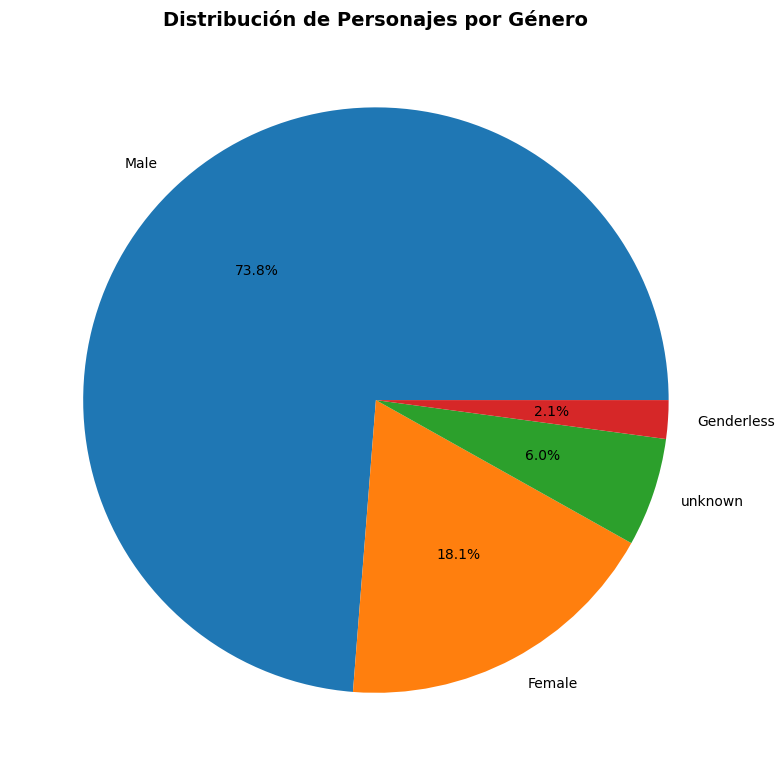

In [11]:
plt.figure(figsize=(8,8))

df_limpio["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title(
    "Distribución de Personajes por Género",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Diagrama de barras, distribución de especies mas frecuentes


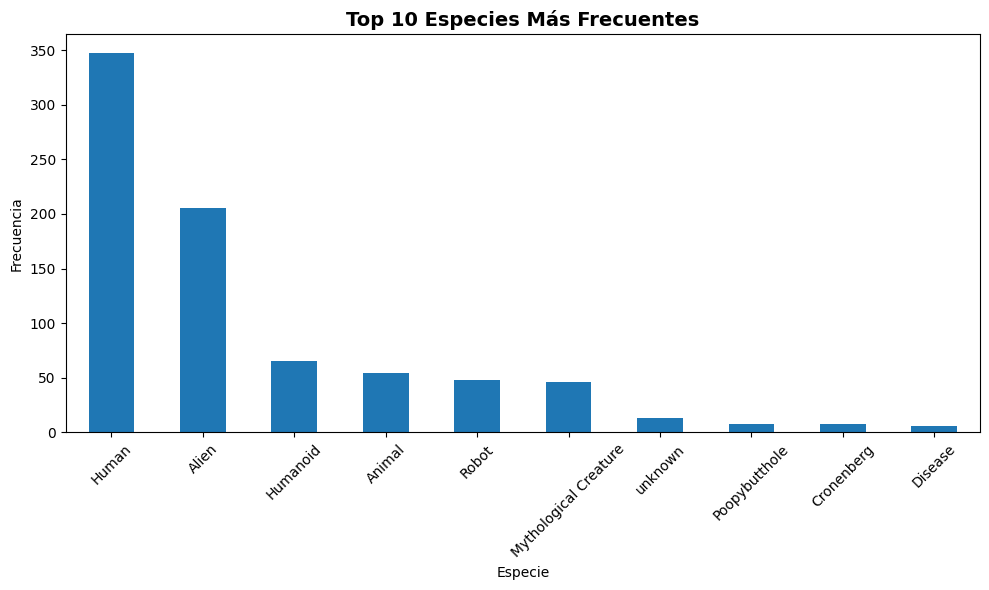

In [12]:
plt.figure(figsize=(10,6))

df_limpio["species"].value_counts().head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Especies Más Frecuentes",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Especie")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Variable - episode_count

In [14]:
df["episode_count"] = df["episode"].apply(len)

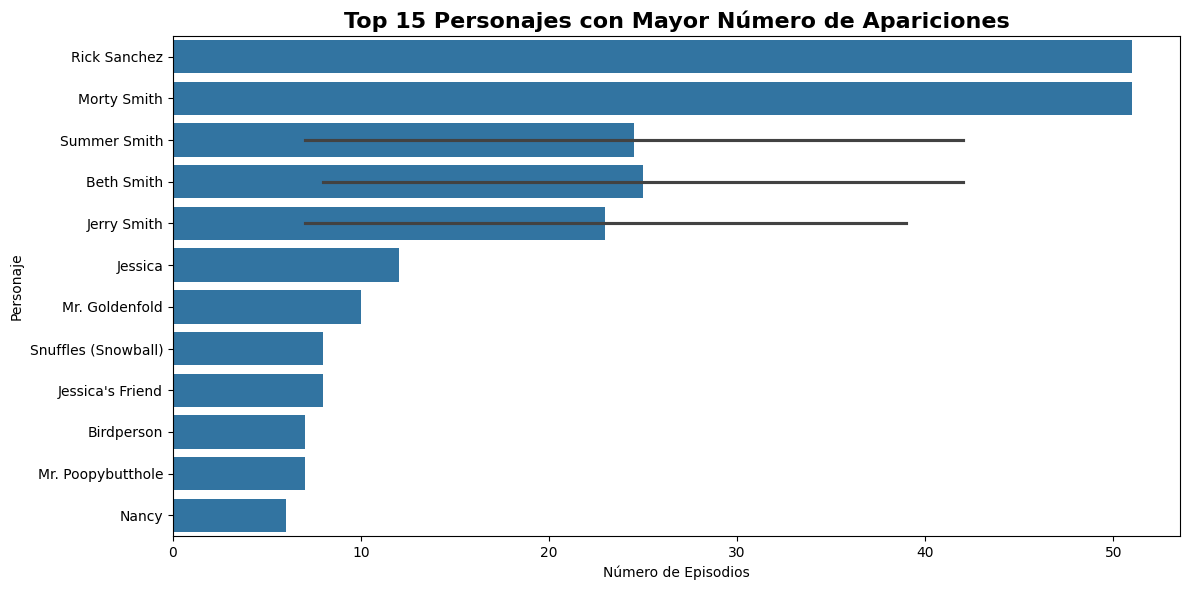

In [17]:
# Crear variable numérica
df["episode_count"] = df["episode"].apply(len)

top_personajes = (
    df[["name", "episode_count"]]
    .sort_values("episode_count", ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_personajes,
    x="episode_count",
    y="name"
)

plt.title(
    "Top 15 Personajes con Mayor Número de Apariciones",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Número de Episodios")
plt.ylabel("Personaje")

plt.tight_layout()
plt.show()